In [2]:
# Install required libraries
!pip install lifetimes plotly scikit-learn shap --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Lifetimes — BG/NBD + Gamma-Gamma
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
from lifetimes.utils import summary_data_from_transaction_data

# sklearn — RFM Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Month name order for sorting
MONTH_ORDER = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f141e',
    'axes.facecolor':   '#0f141e',
    'axes.edgecolor':   '#1e293b',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1e293b',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5
})



Libraries loaded


In [5]:
# Load dataset
superstore = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print(f'Raw shape: {superstore.shape}')
print(f'Columns: {superstore.columns.tolist()}')
superstore.head()

Raw shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Missing values & duplicates
print('=== Missing Values ===')
print(superstore.isnull().sum())
print(f'\nDuplicate rows: {superstore.duplicated().sum()}')

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


In [7]:
# Cleaning

# 1. Parse dates
superstore['Order Date'] = pd.to_datetime(superstore['Order Date'])
superstore['Ship Date']  = pd.to_datetime(superstore['Ship Date'])

# 2. Remove negative/zero sales (returns)
superstore = superstore[superstore['Sales'] > 0].copy()

# 3. Remove duplicates
superstore.drop_duplicates(inplace=True)

#  Feature Engineering — Date Columns

# Year
superstore['Year'] = superstore['Order Date'].dt.year

# Month number (1–12)
superstore['Month_Num'] = superstore['Order Date'].dt.month

# Month Name (January, February ...)
superstore['Month_Name'] = superstore['Order Date'].dt.strftime('%B')

# Month Name as ordered categorical so charts sort correctly
superstore['Month_Name'] = pd.Categorical(
    superstore['Month_Name'], categories=MONTH_ORDER, ordered=True)

# Year-Month Period (for cohort analysis only)
superstore['YearMonth'] = superstore['Order Date'].dt.to_period('M')

# Day of Week
superstore['Day_Name'] = superstore['Order Date'].dt.strftime('%A')

print(f'Clean shape:      {superstore.shape}')
print(f'Date range:       {superstore["Order Date"].min().date()} → {superstore["Order Date"].max().date()}')
print(f'Unique customers: {superstore["Customer ID"].nunique():,}')
print(f'Unique orders:    {superstore["Order ID"].nunique():,}')
print(f'Total Sales:      ${superstore["Sales"].sum():,.2f}')
print(f'Years covered:    {sorted(superstore["Year"].unique())}')
print(f'\nDate columns added:')
print(superstore[['Order Date','Year','Month_Num','Month_Name','Day_Name']].head(8))

Clean shape:      (9994, 26)
Date range:       2014-01-03 → 2017-12-30
Unique customers: 793
Unique orders:    5,009
Total Sales:      $2,297,200.86
Years covered:    [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]

Date columns added:
  Order Date  Year  Month_Num Month_Name Day_Name
0 2016-11-08  2016         11   November  Tuesday
1 2016-11-08  2016         11   November  Tuesday
2 2016-06-12  2016          6       June   Sunday
3 2015-10-11  2015         10    October   Sunday
4 2015-10-11  2015         10    October   Sunday
5 2014-06-09  2014          6       June   Monday
6 2014-06-09  2014          6       June   Monday
7 2014-06-09  2014          6       June   Monday


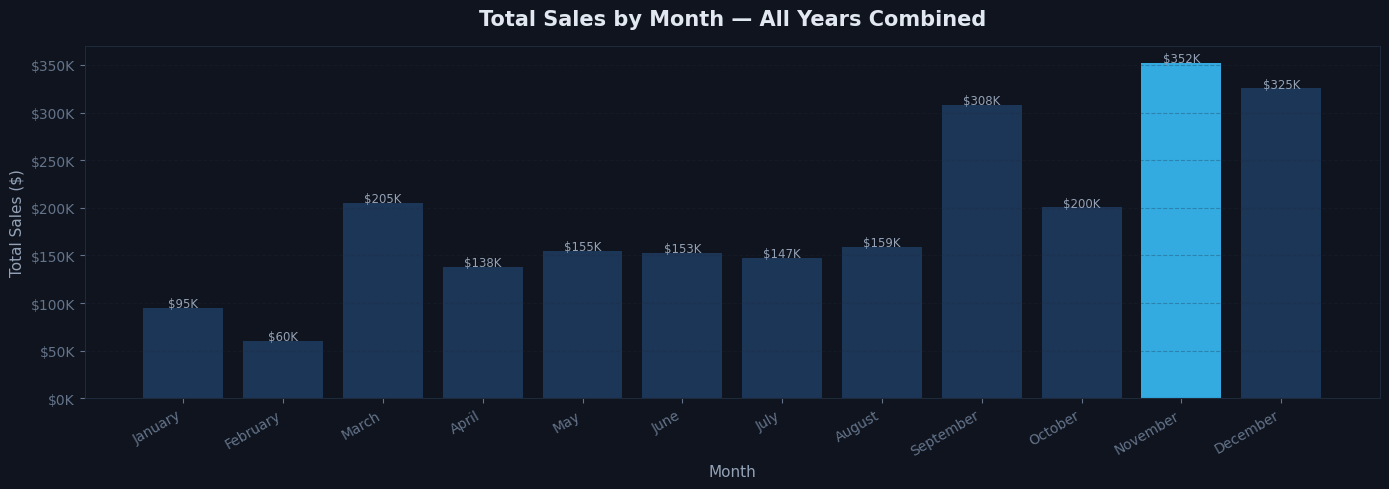

Peak month: November


In [8]:
# Monthly Sales — by Month Name (all years combined)
monthly_sales = (superstore.groupby('Month_Name', observed=True)['Sales']
                 .sum().reset_index()
                 .sort_values('Month_Name'))  # sorts by categorical order Jan→Dec

fig, ax = plt.subplots(figsize=(14, 5))
colors_monthly = ['#38bdf8' if v == monthly_sales['Sales'].max()
                  else '#1e3a5f' for v in monthly_sales['Sales']]
bars = ax.bar(monthly_sales['Month_Name'], monthly_sales['Sales'],
              color=colors_monthly, alpha=0.9)

# Annotate bars
for bar, val in zip(bars, monthly_sales['Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${val/1e3:.0f}K', ha='center', fontsize=8.5, color='#94a3b8')

ax.set_title('Total Sales by Month — All Years Combined',
             fontsize=15, fontweight='bold', color='#e2e8f0', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Sales ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('sales_by_month_name.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()
print('Peak month:', monthly_sales.loc[monthly_sales["Sales"].idxmax(), "Month_Name"])

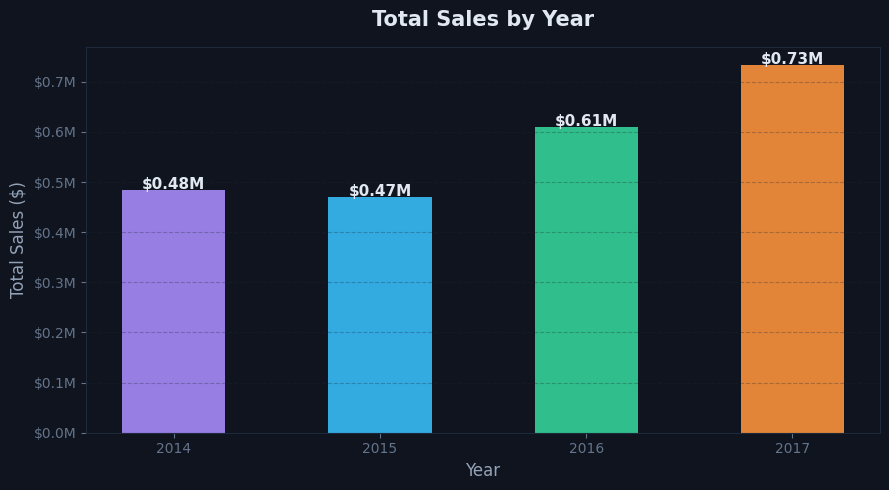

2014 → 2015: -2.8% YoY growth
2015 → 2016: +29.5% YoY growth
2016 → 2017: +20.4% YoY growth


In [9]:
# Sales by Year
yearly_sales = superstore.groupby('Year')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
colors_year = ['#a78bfa','#38bdf8','#34d399','#fb923c'][:len(yearly_sales)]
bars = ax.bar(yearly_sales['Year'].astype(str), yearly_sales['Sales'],
              color=colors_year, alpha=0.9, width=0.5)

for bar, val in zip(bars, yearly_sales['Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${val/1e6:.2f}M', ha='center', fontsize=11, color='#e2e8f0', fontweight='bold')

ax.set_title('Total Sales by Year', fontsize=15, fontweight='bold', color='#e2e8f0', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('sales_by_year.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

# YoY growth
for i in range(1, len(yearly_sales)):
    growth = (yearly_sales['Sales'].iloc[i] - yearly_sales['Sales'].iloc[i-1]) / yearly_sales['Sales'].iloc[i-1] * 100
    print(f'{int(yearly_sales["Year"].iloc[i-1])} → {int(yearly_sales["Year"].iloc[i])}: {growth:+.1f}% YoY growth')

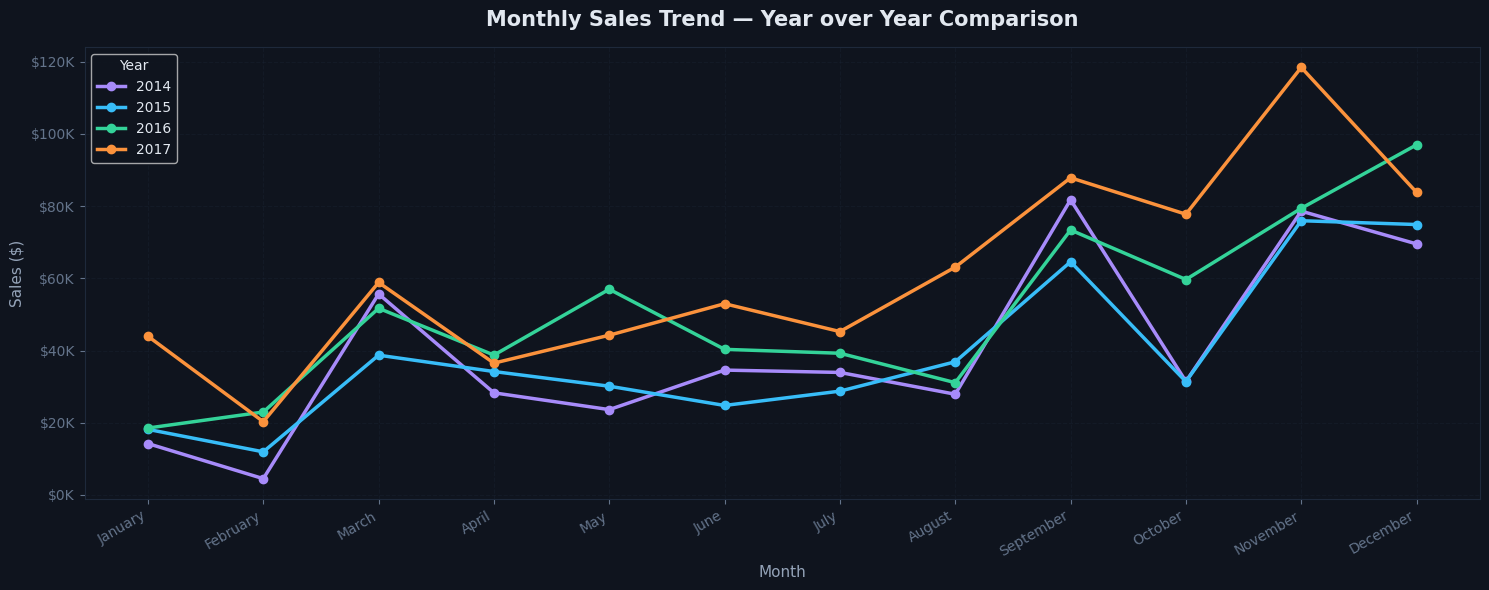

In [10]:
# Monthly Sales — per year, side by side
monthly_yearly = (superstore.groupby(['Year','Month_Name'], observed=True)['Sales']
                  .sum().reset_index()
                  .sort_values(['Year','Month_Name']))

years   = sorted(monthly_yearly['Year'].unique())
n_years = len(years)
colors_lines = ['#a78bfa','#38bdf8','#34d399','#fb923c'][:n_years]

fig, ax = plt.subplots(figsize=(15, 6))
for year, color in zip(years, colors_lines):
    data = monthly_yearly[monthly_yearly['Year'] == year]
    ax.plot(data['Month_Name'].astype(str), data['Sales'],
            marker='o', linewidth=2.5, markersize=6,
            label=str(year), color=color)

ax.set_title('Monthly Sales Trend — Year over Year Comparison',
             fontsize=15, fontweight='bold', color='#e2e8f0', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Sales ($)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend(title='Year', fontsize=10, title_fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('sales_monthly_by_year.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

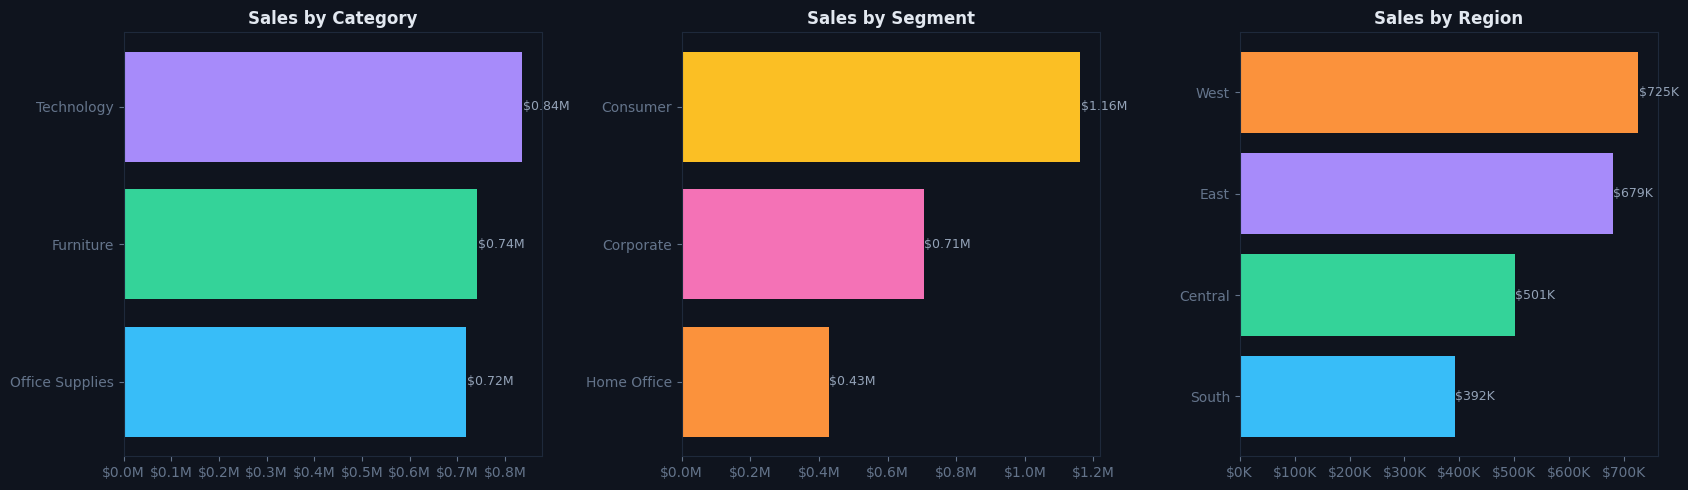

In [11]:
# Category / Segment / Region breakdown
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Category
cat = superstore.groupby('Category')['Sales'].sum().sort_values()
axes[0].barh(cat.index, cat.values, color=['#38bdf8','#34d399','#a78bfa'])
for i, (idx, val) in enumerate(cat.items()):
    axes[0].text(val + 1000, i, f'${val/1e6:.2f}M', va='center', fontsize=9, color='#94a3b8')
axes[0].set_title('Sales by Category', fontsize=12, fontweight='bold', color='#e2e8f0')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Segment
seg = superstore.groupby('Segment')['Sales'].sum().sort_values()
axes[1].barh(seg.index, seg.values, color=['#fb923c','#f472b6','#fbbf24'])
for i, (idx, val) in enumerate(seg.items()):
    axes[1].text(val + 1000, i, f'${val/1e6:.2f}M', va='center', fontsize=9, color='#94a3b8')
axes[1].set_title('Sales by Segment', fontsize=12, fontweight='bold', color='#e2e8f0')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Region
reg = superstore.groupby('Region')['Sales'].sum().sort_values()
axes[2].barh(reg.index, reg.values, color=['#38bdf8','#34d399','#a78bfa','#fb923c'])
for i, (idx, val) in enumerate(reg.items()):
    axes[2].text(val + 500, i, f'${val/1e3:.0f}K', va='center', fontsize=9, color='#94a3b8')
axes[2].set_title('Sales by Region', fontsize=12, fontweight='bold', color='#e2e8f0')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('eda_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

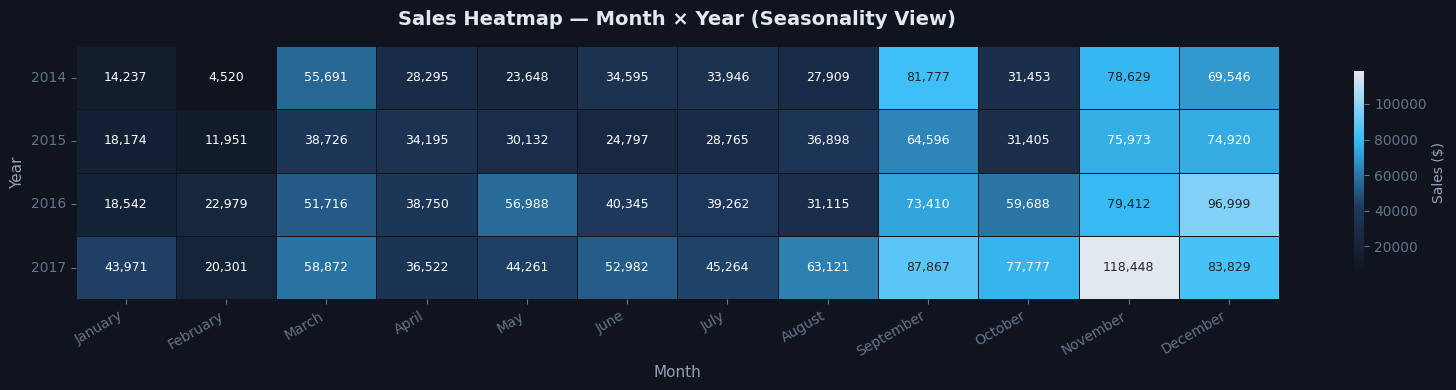

Seasonality heatmap saved


In [12]:
# Month × Year Heatmap — shows seasonality clearly
heat_data = (superstore.groupby(['Year','Month_Name'], observed=True)['Sales']
             .sum().reset_index()
             .pivot(index='Year', columns='Month_Name', values='Sales'))

# Ensure columns are in correct month order
heat_data = heat_data[MONTH_ORDER]

cmap_heat = mcolors.LinearSegmentedColormap.from_list(
    'heat', ['#0f141e','#1e3a5f','#38bdf8','#e2e8f0'])

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(heat_data, annot=True, fmt=',.0f', cmap=cmap_heat,
            linewidths=0.5, linecolor='#0f141e', ax=ax,
            cbar_kws={'label':'Sales ($)', 'shrink':0.8},
            annot_kws={'size':9})
ax.set_title('Sales Heatmap — Month × Year (Seasonality View)',
             fontsize=14, fontweight='bold', color='#e2e8f0', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('sales_heatmap_month_year.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()
print('Seasonality heatmap saved')

In [13]:
# Calculate RFM
reference_date = superstore['Order Date'].max() + pd.Timedelta(days=1)

rfm = superstore.groupby('Customer ID').agg(
    Recency   = ('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency = ('Order ID',   'nunique'),
    Monetary  = ('Sales',      'sum'),
    Segment   = ('Segment',    'first'),
    Region    = ('Region',     'first')
).reset_index()

print('RFM Summary')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))
print(f'\nTotal customers: {len(rfm):,}')
rfm.head()

=== RFM Summary ===
       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    147.80       6.32   2896.85
std     186.21       2.55   2628.67
min       1.00       1.00      4.83
25%      31.00       5.00   1146.05
50%      76.00       6.00   2256.39
75%     184.00       8.00   3785.28
max    1166.00      17.00  25043.05

Total customers: 793


,Customer ID,Recency,Frequency,Monetary,Segment,Region
0,AA-10315,185,5,5563.560,Consumer,Central
1,AA-10375,20,9,1056.390,Consumer,West
2,AA-10480,260,4,1790.512,Consumer,South
3,AA-10645,56,6,5086.935,Consumer,East
4,AB-10015,416,3,886.156,Consumer,West


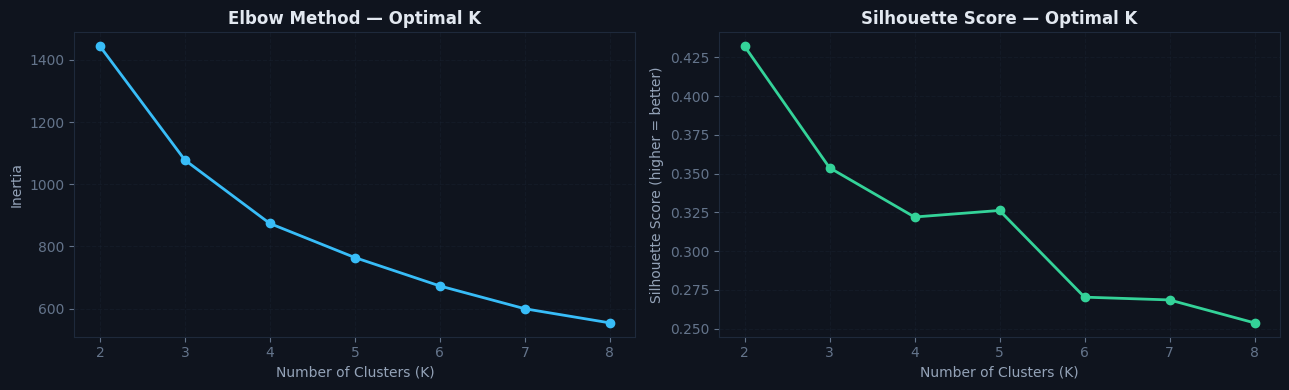

Optimal K by Silhouette Score: 2


In [14]:
#  Log-transform & scale
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Find optimal K — Elbow + Silhouette
inertias    = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias,    color='#38bdf8', marker='o', linewidth=2)
axes[0].set_title('Elbow Method — Optimal K', fontsize=12, fontweight='bold', color='#e2e8f0')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, color='#34d399', marker='o', linewidth=2)
axes[1].set_title('Silhouette Score — Optimal K', fontsize=12, fontweight='bold', color='#e2e8f0')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f'Optimal K by Silhouette Score: {best_k}')

In [15]:
# Fit K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster profiles
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print('=== Cluster Profiles (Raw Means) ===')
print(cluster_summary)

# Auto-label clusters
monetary_rank = cluster_summary['Monetary'].rank(ascending=False)
freq_rank     = cluster_summary['Frequency'].rank(ascending=False)
recency_rank  = cluster_summary['Recency'].rank(ascending=True)

def label_cluster(c):
    if monetary_rank[c] == 1 and recency_rank[c] <= 2:
        return 'Champions'
    elif monetary_rank[c] <= 2 and freq_rank[c] <= 2:
        return 'Loyal Customers'
    elif recency_rank[c] == 1:
        return 'Recent Customers'
    elif recency_rank[c] >= best_k - 1:
        return 'At Risk'
    else:
        return 'Needs Attention'

cluster_labels        = {c: label_cluster(c) for c in range(best_k)}
rfm['Segment_KMeans'] = rfm['Cluster'].map(cluster_labels)

print('\n Segment Distribution ')
print(rfm['Segment_KMeans'].value_counts())

=== Cluster Profiles (Raw Means) ===
         Recency  Frequency  Monetary
Cluster                              
0         314.84       3.68   1001.95
1          84.87       7.31   3610.72

=== Segment Distribution ===
Segment_KMeans
Champions          576
Loyal Customers    217
Name: count, dtype: int64


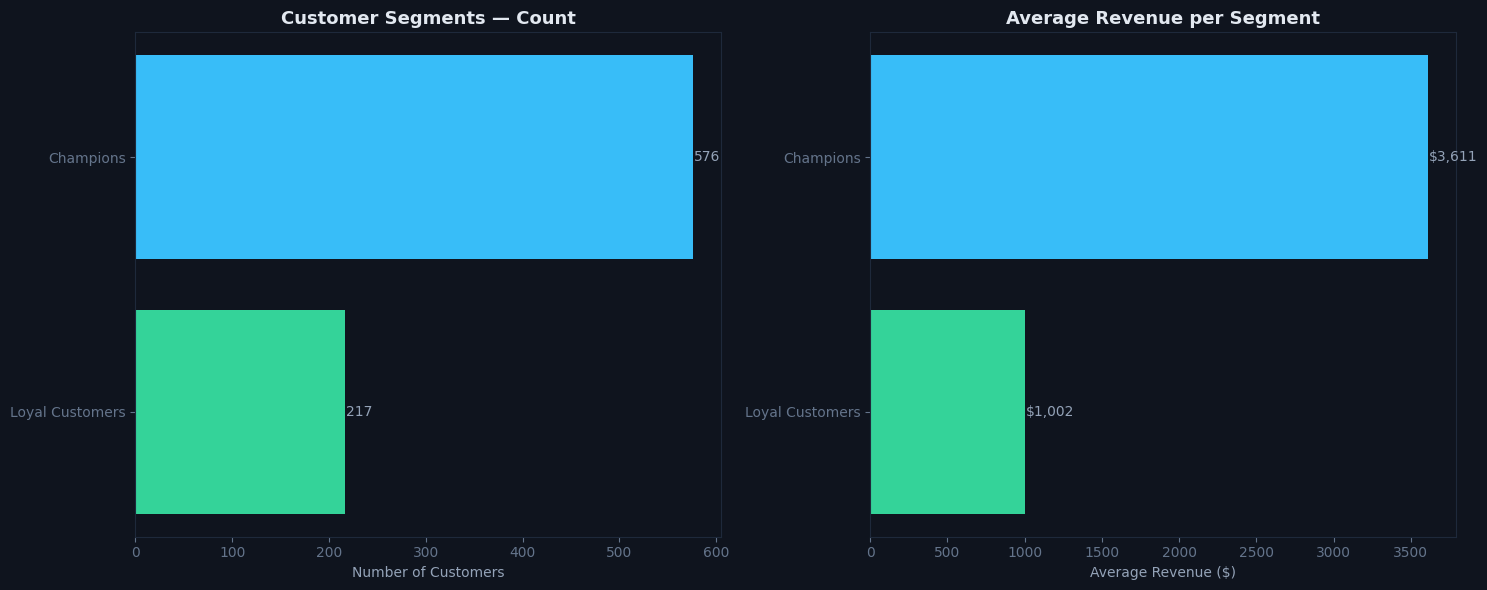

In [16]:
# RFM Visualisations
seg_colors = {
    'Champions':       '#38bdf8',
    'Loyal Customers': '#34d399',
    'Recent Customers':'#fb923c',
    'At Risk':         '#f87171',
    'Needs Attention': '#94a3b8'
}

seg_summary = rfm.groupby('Segment_KMeans').agg(
    Count       = ('Customer ID', 'count'),
    Avg_Revenue = ('Monetary',    'mean'),
    Avg_Freq    = ('Frequency',   'mean'),
    Avg_Recency = ('Recency',     'mean')
).reset_index().sort_values('Avg_Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Count
colors_bar = [seg_colors.get(s, '#64748b') for s in seg_summary['Segment_KMeans']]
bars = axes[0].barh(seg_summary['Segment_KMeans'][::-1],
                    seg_summary['Count'][::-1], color=colors_bar[::-1])
for bar, val in zip(bars, seg_summary['Count'][::-1]):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10, color='#94a3b8')
axes[0].set_title('Customer Segments — Count', fontsize=13, fontweight='bold', color='#e2e8f0')
axes[0].set_xlabel('Number of Customers')

# Revenue
bars2 = axes[1].barh(seg_summary['Segment_KMeans'][::-1],
                     seg_summary['Avg_Revenue'][::-1], color=colors_bar[::-1])
for bar, val in zip(bars2, seg_summary['Avg_Revenue'][::-1]):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=10, color='#94a3b8')
axes[1].set_title('Average Revenue per Segment', fontsize=13, fontweight='bold', color='#e2e8f0')
axes[1].set_xlabel('Average Revenue ($)')

plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

In [17]:
# 3D RFM Scatter
fig = px.scatter_3d(
    rfm,
    x='Recency', y='Frequency', z='Monetary',
    color='Segment_KMeans',
    color_discrete_map=seg_colors,
    title='RFM Segmentation — K-Means Clustering (3D View)',
    labels={'Recency':'Recency (days)','Frequency':'Orders','Monetary':'Revenue ($)'},
    opacity=0.75
)
fig.update_layout(paper_bgcolor='#0f141e', plot_bgcolor='#0f141e',
                  font_color='#e2e8f0', title_font_size=14)
fig.show()

In [30]:
# RFM sanity check
print('=== RFM Segment Summary ===')
print(rfm['Segment_KMeans'].value_counts())
print(f'\nTotal customers: {len(rfm):,}')
print(f'\nRFM means by segment:')
print(rfm.groupby('Segment_KMeans')[['Recency','Frequency','Monetary']].mean().round(2))

=== RFM Segment Summary ===
Segment_KMeans
Champions          576
Loyal Customers    217
Name: count, dtype: int64

Total customers: 793

RFM means by segment:
                 Recency  Frequency  Monetary
Segment_KMeans                               
Champions          84.87       7.31   3610.72
Loyal Customers   314.84       3.68   1001.95


In [18]:
# Preparing transaction summary
observation_period_end = superstore['Order Date'].max()

ltv_summary = summary_data_from_transaction_data(
    superstore,
    customer_id_col        = 'Customer ID',
    datetime_col           = 'Order Date',
    monetary_value_col     = 'Sales',
    observation_period_end = observation_period_end,
    freq = 'D'
)

# Gamma-Gamma requires repeat purchasers only
ltv_summary = ltv_summary[ltv_summary['frequency'] > 0]

print(f'Customers with repeat purchases: {len(ltv_summary):,}')
print(f'\nTransaction Summary')
print(ltv_summary.describe().round(2))
ltv_summary.head()

Customers with repeat purchases: 781

=== Transaction Summary ===
       frequency  recency        T  monetary_value
count     781.00   781.00   781.00          781.00
mean        5.38  1015.01  1158.13          453.27
std         2.47   286.16   235.78          444.18
min         1.00     2.00    55.00            2.81
25%         4.00   846.00  1100.00          198.45
50%         5.00  1095.00  1208.00          340.85
75%         7.00  1223.00  1329.00          575.84
max        16.00  1440.00  1457.00         4737.96


,frequency,recency,T,monetary_value
Customer ID,,,,
AA-10315,4.0,1186.0,1370.0,1209.25300
AA-10375,8.0,1330.0,1349.0,129.98375
AA-10480,3.0,1077.0,1336.0,587.68400
AA-10645,5.0,1232.0,1287.0,796.03300
AB-10015,2.0,996.0,1411.0,436.76600


In [21]:
# Fit BG/NBD Model

# increasing penalizer until convergence
for penalizer in [0.01, 0.1, 0.5, 1.0]:
    try:
        bgf = BetaGeoFitter(penalizer_coef=penalizer)
        bgf.fit(ltv_summary['frequency'], ltv_summary['recency'], ltv_summary['T'])
        print(f'BG/NBD model fitted  (penalizer={penalizer})')
        print(bgf.summary)
        break
    except Exception as e:
        print(f'penalizer={penalizer} failed → trying higher...')

Fitting BG/NBD model...
BG/NBD model fitted  (penalizer=0.01)
               coef      se(coef)  lower 95% bound  upper 95% bound
r      3.102387e+00  1.486123e-01     2.811107e+00     3.393667e+00
alpha  6.595650e+02  3.590630e+01     5.891886e+02     7.299413e+02
a      1.129872e-16  4.548636e-12    -8.915213e-12     8.915439e-12
b      9.082046e-05  1.789140e-01    -3.505807e-01     3.507623e-01


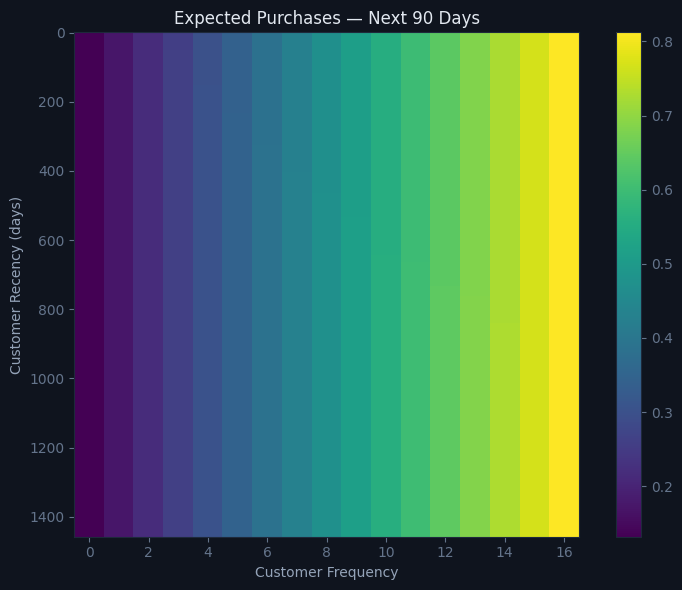

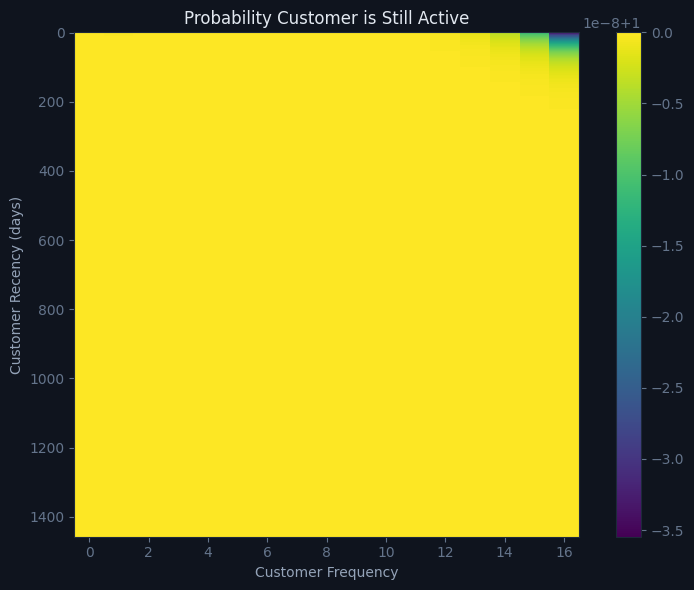

BG/NBD matrices saved ✅


In [24]:
# Frequency / Recency & Probability Alive matrices
# Plotting separately to avoid lifetimes internal subplot conflicts

# Plot 1 — Expected Purchases Next 90 Days
fig1, ax1 = plt.subplots(figsize=(8, 6))
plot_frequency_recency_matrix(bgf, T=90,
    title='Expected Purchases — Next 90 Days',
    xlabel='Customer Frequency',
    ylabel='Customer Recency (days)')
plt.tight_layout()
plt.savefig('bgnbd_frequency_recency.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

# Plot 2 — Probability Still Active
fig2, ax2 = plt.subplots(figsize=(8, 6))
plot_probability_alive_matrix(bgf,
    title='Probability Customer is Still Active',
    xlabel='Customer Frequency',
    ylabel='Customer Recency (days)')
plt.tight_layout()
plt.savefig('bgnbd_prob_alive.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

print('BG/NBD matrices saved')

In [25]:
# Predict future purchases at 90 / 180 / 365 days
for days in [90, 180, 365]:
    col = f'pred_purchases_{days}d'
    ltv_summary[col] = bgf.conditional_expected_number_of_purchases_up_to_time(
        days, ltv_summary['frequency'], ltv_summary['recency'], ltv_summary['T'])

ltv_summary['prob_alive'] = bgf.conditional_probability_alive(
    ltv_summary['frequency'], ltv_summary['recency'], ltv_summary['T'])

print('Predicted Purchases')
print(f"Avg predicted purchases — 90d:  {ltv_summary['pred_purchases_90d'].mean():.2f}")
print(f"Avg predicted purchases — 180d: {ltv_summary['pred_purchases_180d'].mean():.2f}")
print(f"Avg predicted purchases — 365d: {ltv_summary['pred_purchases_365d'].mean():.2f}")
print(f"Avg probability still alive:    {ltv_summary['prob_alive'].mean():.2%}")

=== Predicted Purchases ===
Avg predicted purchases — 90d:  0.42
Avg predicted purchases — 180d: 0.85
Avg predicted purchases — 365d: 1.71
Avg probability still alive:    100.00%


In [26]:
# Fit Gamma-Gamma Model
corr = ltv_summary[['frequency','monetary_value']].corr().iloc[0,1]
print(f'Frequency–Monetary correlation: {corr:.4f} (needs to be < 0.3)')

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(ltv_summary['frequency'], ltv_summary['monetary_value'])
print('Gamma-Gamma model fitted')
print(ggf.summary)

Frequency–Monetary correlation: -0.0074 (needs to be < 0.3)
Gamma-Gamma model fitted
        coef  se(coef)  lower 95% bound  upper 95% bound
p   9.787309  0.489400         8.828084        10.746533
q   0.718486  0.031397         0.656947         0.780024
v  10.139721  0.518610         9.123245        11.156197


In [27]:
# Predict LTV — 12 months
ltv_summary['exp_avg_order_value'] = ggf.conditional_expected_average_profit(
    ltv_summary['frequency'], ltv_summary['monetary_value'])

ltv_summary['LTV_12M'] = ggf.customer_lifetime_value(
    bgf,
    ltv_summary['frequency'],
    ltv_summary['recency'],
    ltv_summary['T'],
    ltv_summary['monetary_value'],
    time          = 12,    # 12 months
    discount_rate = 0.01,  # 1% monthly = ~12% annual
    freq          = 'D'
)

print(' 12-Month LTV Predictions')
print(f"Average LTV:    ${ltv_summary['LTV_12M'].mean():,.2f}")
print(f"Median LTV:     ${ltv_summary['LTV_12M'].median():,.2f}")
print(f"Top 10% LTV:    ${ltv_summary['LTV_12M'].quantile(0.9):,.2f}")
print(f"Top 1%  LTV:    ${ltv_summary['LTV_12M'].quantile(0.99):,.2f}")
ltv_summary[['frequency','recency','monetary_value','prob_alive',
             'pred_purchases_365d','LTV_12M']].head(10)

=== 12-Month LTV Predictions ===
Average LTV:    $723.75
Median LTV:     $574.64
Top 10% LTV:    $1,450.82
Top 1%  LTV:    $3,163.02


,frequency,recency,monetary_value,prob_alive,pred_purchases_365d,LTV_12M
Customer ID,,,,,,
AA-10315,4.0,1186.0,1209.253000,1.0,1.277304,1442.221351
AA-10375,8.0,1330.0,129.983750,1.0,2.017545,245.848641
AA-10480,3.0,1077.0,587.684000,1.0,1.116161,616.200458
AA-10645,5.0,1232.0,796.033000,1.0,1.519277,1128.120290
AB-10015,2.0,996.0,436.766000,1.0,0.899451,372.997910
AB-10060,7.0,780.0,1105.297143,1.0,2.468839,2538.081972
AB-10105,9.0,1065.0,1485.101222,1.0,2.501959,3450.902163
AB-10150,4.0,1355.0,65.287000,1.0,1.261148,79.697958
AB-10165,7.0,1115.0,153.791714,1.0,2.049035,295.473626


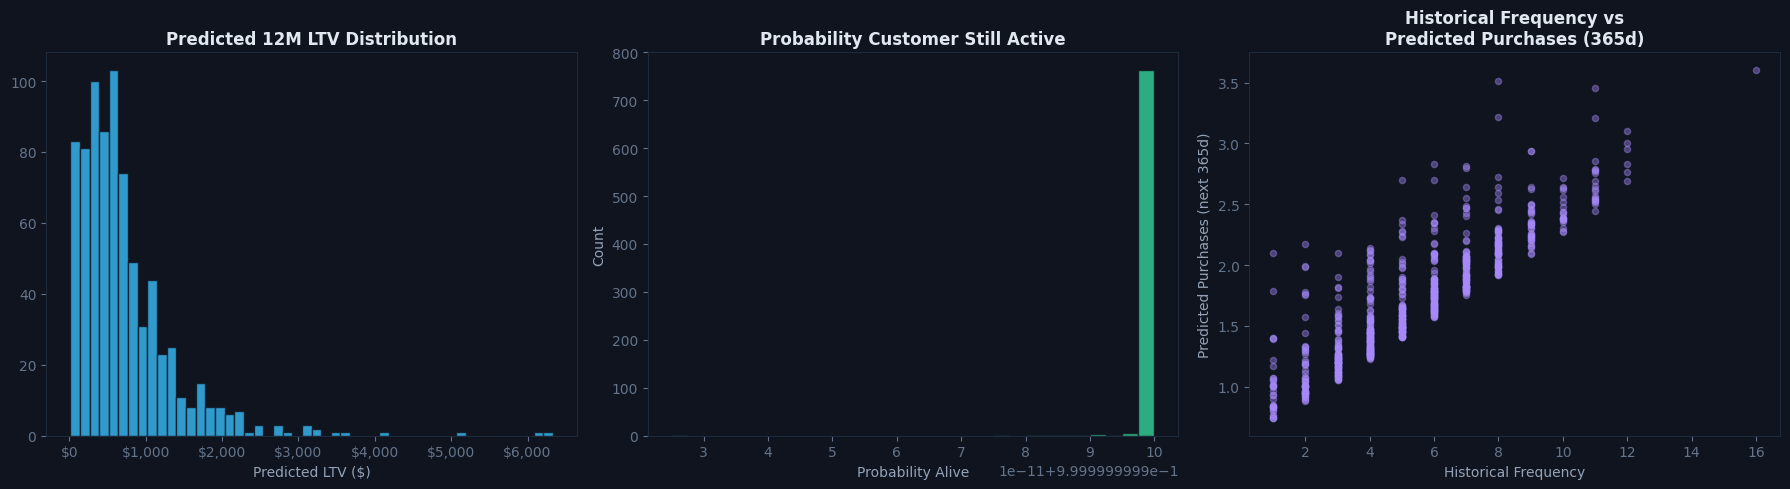

In [28]:
# LTV Visualisations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LTV distribution
axes[0].hist(ltv_summary['LTV_12M'], bins=50, color='#38bdf8', alpha=0.8, edgecolor='#0f141e')
axes[0].set_title('Predicted 12M LTV Distribution', fontsize=12, fontweight='bold', color='#e2e8f0')
axes[0].set_xlabel('Predicted LTV ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Probability alive
axes[1].hist(ltv_summary['prob_alive'], bins=30, color='#34d399', alpha=0.8, edgecolor='#0f141e')
axes[1].set_title('Probability Customer Still Active', fontsize=12, fontweight='bold', color='#e2e8f0')
axes[1].set_xlabel('Probability Alive')
axes[1].set_ylabel('Count')

# Predicted purchases scatter
axes[2].scatter(ltv_summary['frequency'], ltv_summary['pred_purchases_365d'],
                alpha=0.4, color='#a78bfa', s=20)
axes[2].set_title('Historical Frequency vs\nPredicted Purchases (365d)',
                  fontsize=12, fontweight='bold', color='#e2e8f0')
axes[2].set_xlabel('Historical Frequency')
axes[2].set_ylabel('Predicted Purchases (next 365d)')

plt.tight_layout()
plt.savefig('ltv_predictions.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

=== LTV by Segment ===
 Segment_KMeans  Customers  Avg_LTV  Total_LTV  Avg_Prob_Alive  Avg_Pred_Orders
      Champions        576   859.18  494888.26             1.0             1.88
Loyal Customers        217   343.23   70361.76             1.0             1.26


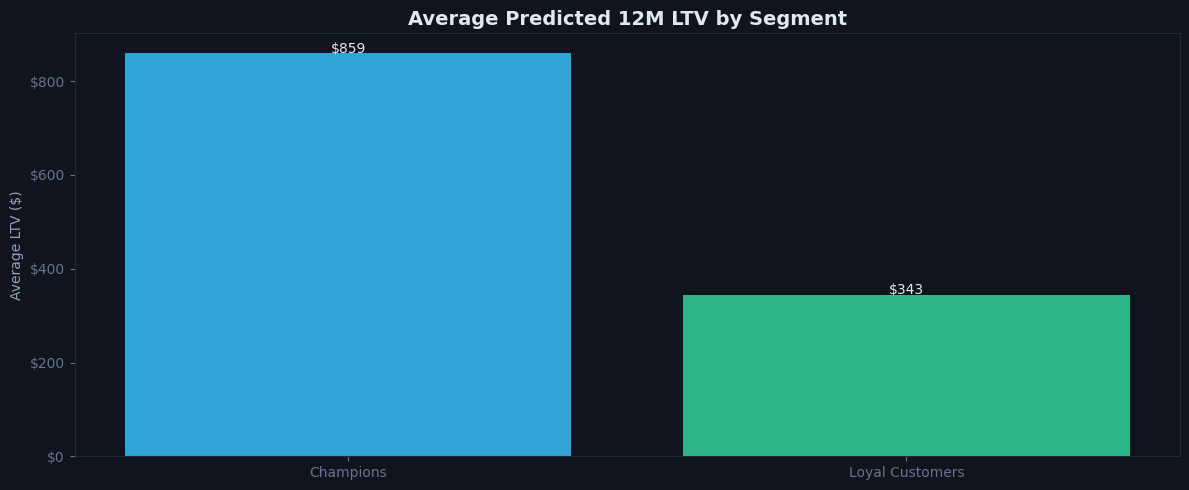

In [29]:
# LTV by RFM Segment
rfm_ltv = rfm.merge(
    ltv_summary[['prob_alive','pred_purchases_365d','LTV_12M']].reset_index(),
    left_on='Customer ID', right_on='Customer ID', how='left'
)

ltv_by_seg = rfm_ltv.groupby('Segment_KMeans').agg(
    Customers       = ('Customer ID',        'count'),
    Avg_LTV         = ('LTV_12M',            'mean'),
    Total_LTV       = ('LTV_12M',            'sum'),
    Avg_Prob_Alive  = ('prob_alive',         'mean'),
    Avg_Pred_Orders = ('pred_purchases_365d', 'mean')
).reset_index().sort_values('Avg_LTV', ascending=False).round(2)

print(' LTV by Segment')
print(ltv_by_seg.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors_s = [seg_colors.get(s, '#64748b') for s in ltv_by_seg['Segment_KMeans']]
bars = ax.bar(ltv_by_seg['Segment_KMeans'], ltv_by_seg['Avg_LTV'], color=colors_s, alpha=0.85)
for bar, val in zip(bars, ltv_by_seg['Avg_LTV']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'${val:,.0f}', ha='center', fontsize=10, color='#e2e8f0')
ax.set_title('Average Predicted 12M LTV by Segment',
             fontsize=14, fontweight='bold', color='#e2e8f0')
ax.set_ylabel('Average LTV ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('ltv_by_segment.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()

In [31]:
# LTV sanity check
print('LTV Summary')
print(f"Customers modelled:       {len(ltv_summary):,}")
print(f"Avg prob alive:           {ltv_summary['prob_alive'].mean():.2%}")
print(f"Avg predicted orders 90d: {ltv_summary['pred_purchases_90d'].mean():.2f}")
print(f"Avg predicted LTV 12M:    ${ltv_summary['LTV_12M'].mean():,.2f}")
print(f"Median predicted LTV 12M: ${ltv_summary['LTV_12M'].median():,.2f}")
print(f"Top 10% LTV:              ${ltv_summary['LTV_12M'].quantile(0.9):,.2f}")
print(f'\n LTV by Segment')
print(ltv_by_seg[['Segment_KMeans','Customers','Avg_LTV','Avg_Prob_Alive']].to_string(index=False))

=== LTV Summary ===
Customers modelled:       781
Avg prob alive:           100.00%
Avg predicted orders 90d: 0.42
Avg predicted LTV 12M:    $723.75
Median predicted LTV 12M: $574.64
Top 10% LTV:              $1,450.82

=== LTV by Segment ===
 Segment_KMeans  Customers  Avg_LTV  Avg_Prob_Alive
      Champions        576   859.18             1.0
Loyal Customers        217   343.23             1.0


In [33]:
# NB
print("Note: prob_alive = 100% across all customers is expected for this dataset.")
print("The Superstore spans only 4 years — the BG/NBD model has insufficient")
print("time to observe customer 'death'. In production, 3+ years of dense")
print("transaction data per customer is needed for reliable prob_alive estimates.")
print("\nThe LTV predictions and purchase forecasts remain valid.")

Note: prob_alive = 100% across all customers is expected for this dataset.
The Superstore spans only 4 years — the BG/NBD model has insufficient
time to observe customer 'death'. In production, 3+ years of dense
transaction data per customer is needed for reliable prob_alive estimates.

The LTV predictions and purchase forecasts remain valid.


In [34]:
# Build cohort data
# First purchase month per customer
superstore['CohortMonth'] = (superstore.groupby('Customer ID')['Order Date']
                              .transform('min').dt.to_period('M'))
superstore['OrderMonth']  = superstore['Order Date'].dt.to_period('M')

# Cohort index = months since first purchase
superstore['CohortIndex'] = (
    superstore['OrderMonth'] - superstore['CohortMonth']).apply(lambda x: x.n)

# Add cohort month name for labelling
superstore['CohortMonthName'] = superstore['CohortMonth'].dt.strftime('%b %Y')

# Pivot table
cohort_data  = (superstore.groupby(['CohortMonth','CohortIndex'])['Customer ID']
                .nunique().reset_index())
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Retention rate
cohort_size      = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Label index with Month Name + Year
retention_matrix.index = retention_matrix.index.strftime('%b %Y')

print(f'Cohort matrix: {retention_matrix.shape}')
print(f'\nFirst 5 cohorts, first 6 months:')
print(retention_matrix.iloc[:5, :6].to_string())

Cohort matrix: (42, 48)

First 5 cohorts, first 6 months:
CohortIndex      0     1    2     3     4     5
CohortMonth                                    
Jan 2014     100.0   9.4  NaN   6.2   6.2   NaN
Feb 2014     100.0  16.7  8.3   4.2   NaN   8.3
Mar 2014     100.0   6.2  3.1  12.3  10.8   NaN
Apr 2014     100.0  10.7  3.6   7.1   5.4  14.3
May 2014     100.0   8.9  8.9   7.1  17.9   3.6


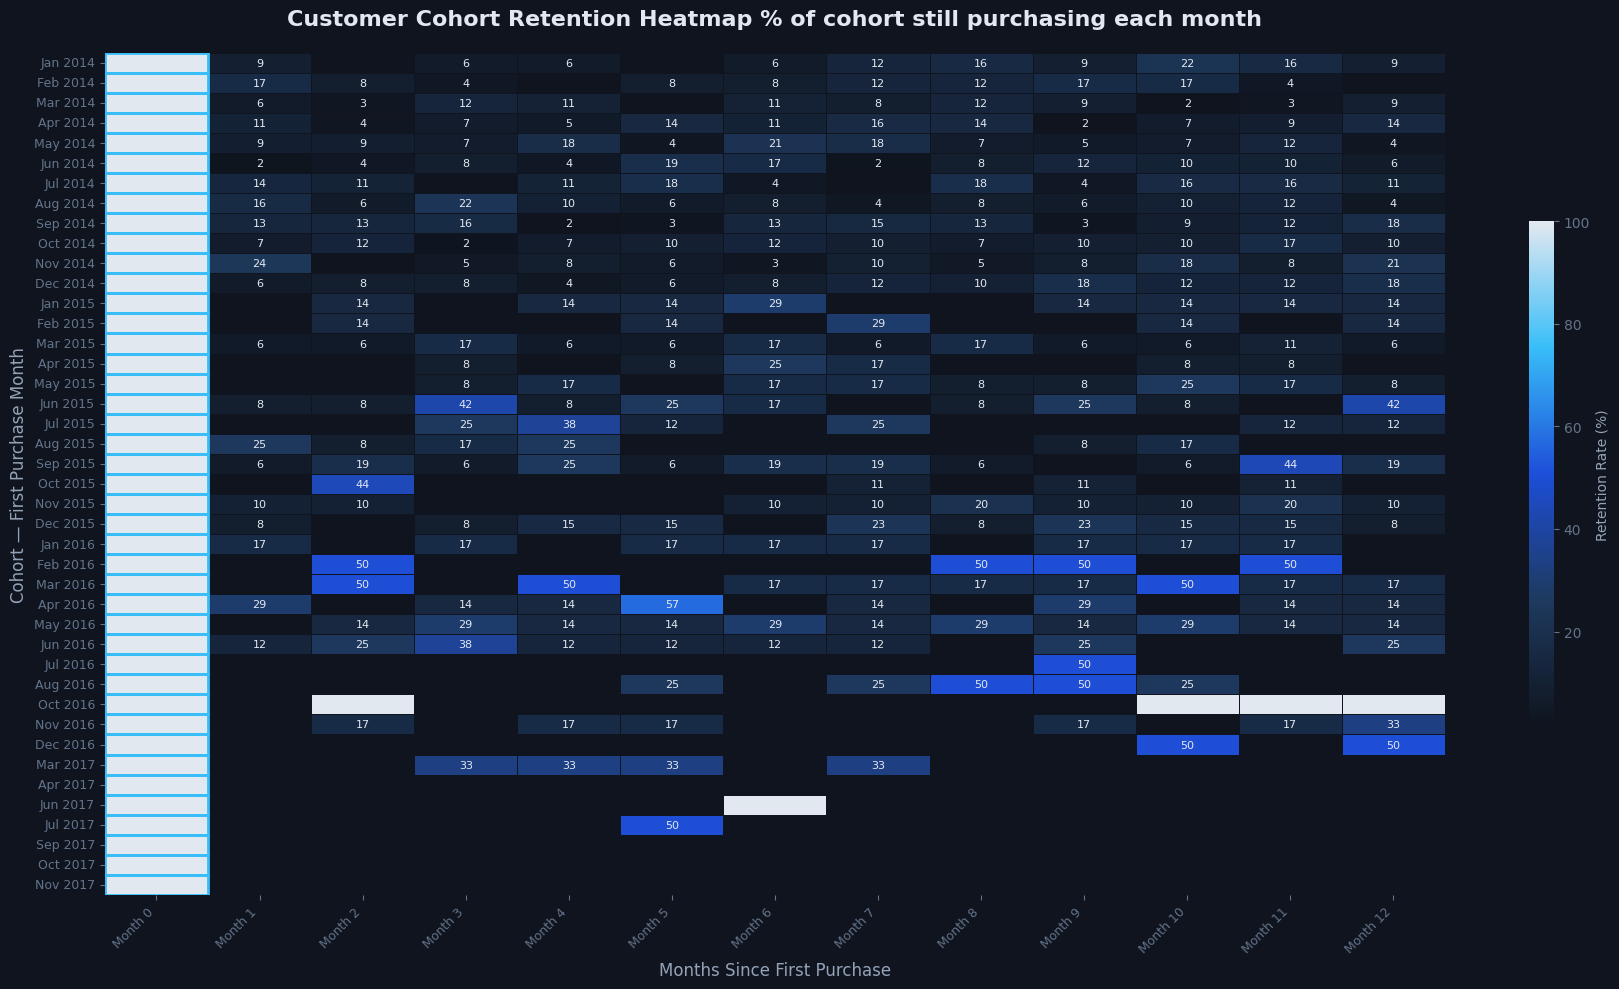

Cohort heatmap saved ✅


In [36]:
# Cohort Retention Heatmap
display_months = min(13, retention_matrix.shape[1])
plot_matrix    = retention_matrix.iloc[:, :display_months]

cmap = mcolors.LinearSegmentedColormap.from_list(
    'retention', ['#0f141e','#1e3a5f','#1d4ed8','#38bdf8','#e2e8f0'])

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(
    plot_matrix,
    annot      = True,
    fmt        = '.0f',
    cmap       = cmap,
    linewidths = 0.5,
    linecolor  = '#0f141e',
    ax         = ax,
    cbar_kws   = {'label': 'Retention Rate (%)', 'shrink': 0.6},
    annot_kws  = {'size': 8, 'color': '#e2e8f0'}
)

ax.set_title('Customer Cohort Retention Heatmap % of cohort still purchasing each month',
             fontsize=16, fontweight='bold', color='#e2e8f0', pad=20)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort — First Purchase Month', fontsize=12)
ax.set_yticklabels(plot_matrix.index, rotation=0, fontsize=9)
ax.set_xticklabels([f'Month {i}' for i in range(display_months)],
                   rotation=45, ha='right', fontsize=9)

# Highlight Month 0 column (always 100%)
for i in range(len(plot_matrix)):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, fill=False, edgecolor='#38bdf8', lw=2))

plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()
print('Cohort heatmap saved')

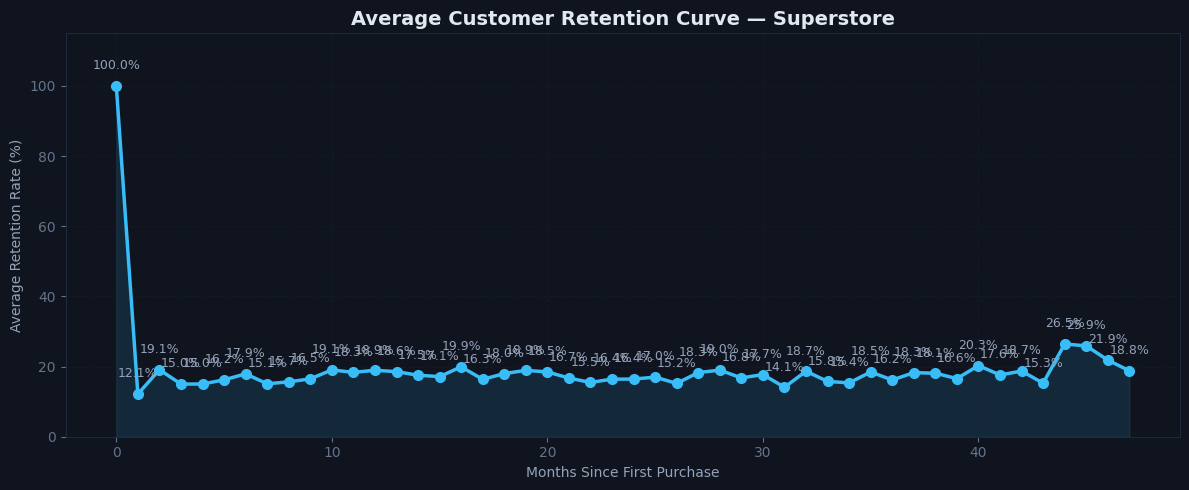

In [37]:
#  Average Retention Curve
avg_retention = retention_matrix.mean(axis=0).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_retention.index, avg_retention.values,
        color='#38bdf8', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(avg_retention.index, avg_retention.values, alpha=0.12, color='#38bdf8')

for x, y in zip(avg_retention.index, avg_retention.values):
    ax.annotate(f'{y:.1f}%', (x, y),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9, color='#94a3b8')

ax.set_title('Average Customer Retention Curve — Superstore',
             fontsize=14, fontweight='bold', color='#e2e8f0')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Average Retention Rate (%)')
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('retention_curve.png', dpi=150, bbox_inches='tight', facecolor='#0f141e')
plt.show()